In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

## Классная работа

## nn.Sequential

### Создание модели без доступа к отдельным слоям

In [5]:
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
model

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

### Создание модели с доступом к отдельным слоям

In [6]:
model = nn.Sequential()
model.add_module('layer1', nn.Linear(784, 128))
model.add_module('relu', nn.ReLU())
model.add_module('layer2', nn.Linear(128, 10))
model, model.layer1

(Sequential(
   (layer1): Linear(in_features=784, out_features=128, bias=True)
   (relu): ReLU()
   (layer2): Linear(in_features=128, out_features=10, bias=True)
 ),
 Linear(in_features=784, out_features=128, bias=True))

### Sequential как часть более крупной модели

In [7]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(28*28, 64)
        self.block = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    
    def forward(self, x):
        x = self.l1(x)
        x = self.clock(x)
        return x

In [9]:
block = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

In [11]:
model = nn.Sequential()
model.add_module('layer1', nn.Linear(784, 128))
model.add_module('relu', nn.ReLU())
model.add_module('block', block)
model

Sequential(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (block): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

## nn.ModuleList

In [13]:
class Model(nn.Module):
    def __init__(self, inp, out, n_layers=3):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(inp//n, inp//(n+1)) for n in range(1, n_layers+1)]) # для регистрации списка слоев
        self.layer_out = nn.Linear(self.layers[-1].out_features, out)

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        x = self.layer_out(x)

        return x
    
model = Model(8, 64)
model

Model(
  (layers): ModuleList(
    (0): Linear(in_features=8, out_features=4, bias=True)
    (1): Linear(in_features=4, out_features=2, bias=True)
    (2): Linear(in_features=2, out_features=2, bias=True)
  )
  (layer_out): Linear(in_features=2, out_features=64, bias=True)
)

In [ ]:
class Model(nn.Module):
    def __init__(self, inp, out, n_layers=3):
        super().__init__()
        self.layers = nn.ModuleList()
        for n in range(1, n_layers+1):
            self.layers.add_module(f'layer{n}', nn.Linear(inp//n, inp//(n+1))) # чтобы можно было обращаться к слоям в модуле по имени
        self.layer_out = nn.Linear(inp//(n+1), out)

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        x = self.layer_out(x)

        return x
    
model = Model(8, 64)
model.layers, model.layers.layer1

(ModuleList(
   (0): Linear(in_features=8, out_features=4, bias=True)
   (1): Linear(in_features=4, out_features=2, bias=True)
   (2): Linear(in_features=2, out_features=2, bias=True)
 ),
 Linear(in_features=8, out_features=4, bias=True))

## nn.ModuleDict

In [19]:
class Model(nn.Module):
    def __init__(self, inp, out, n_layers=3, act_type=None):
        super().__init__()
        self.layers = nn.ModuleList()
        for n in range(1, n_layers+1):
            self.layers.add_module(f'layer{n}', nn.Linear(inp//n, inp//(n+1))) # чтобы можно было обращаться к слоям в модуле по имени
        self.layer_out = nn.Linear(inp//(n+1), out)
        self.act_type = act_type
        # чтобы прменять нужную функцию активации в зависимости от act_type
        self.act_lst = nn.ModuleDict({
            'relu': nn.ReLU(),
            'tanh': nn.Tanh()
        })

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        # пропускаем через нужную функцию активации
        if self.act_type and self.act_type in self.act_lst.keys():
            x = self.act_lst[self.act_type](x)

        return x
    
model = Model(8, 64, act_type='relu')
model.layers, model.act_type

(ModuleList(
   (0): Linear(in_features=8, out_features=4, bias=True)
   (1): Linear(in_features=4, out_features=2, bias=True)
   (2): Linear(in_features=2, out_features=2, bias=True)
 ),
 'relu')

## Домашняя работа

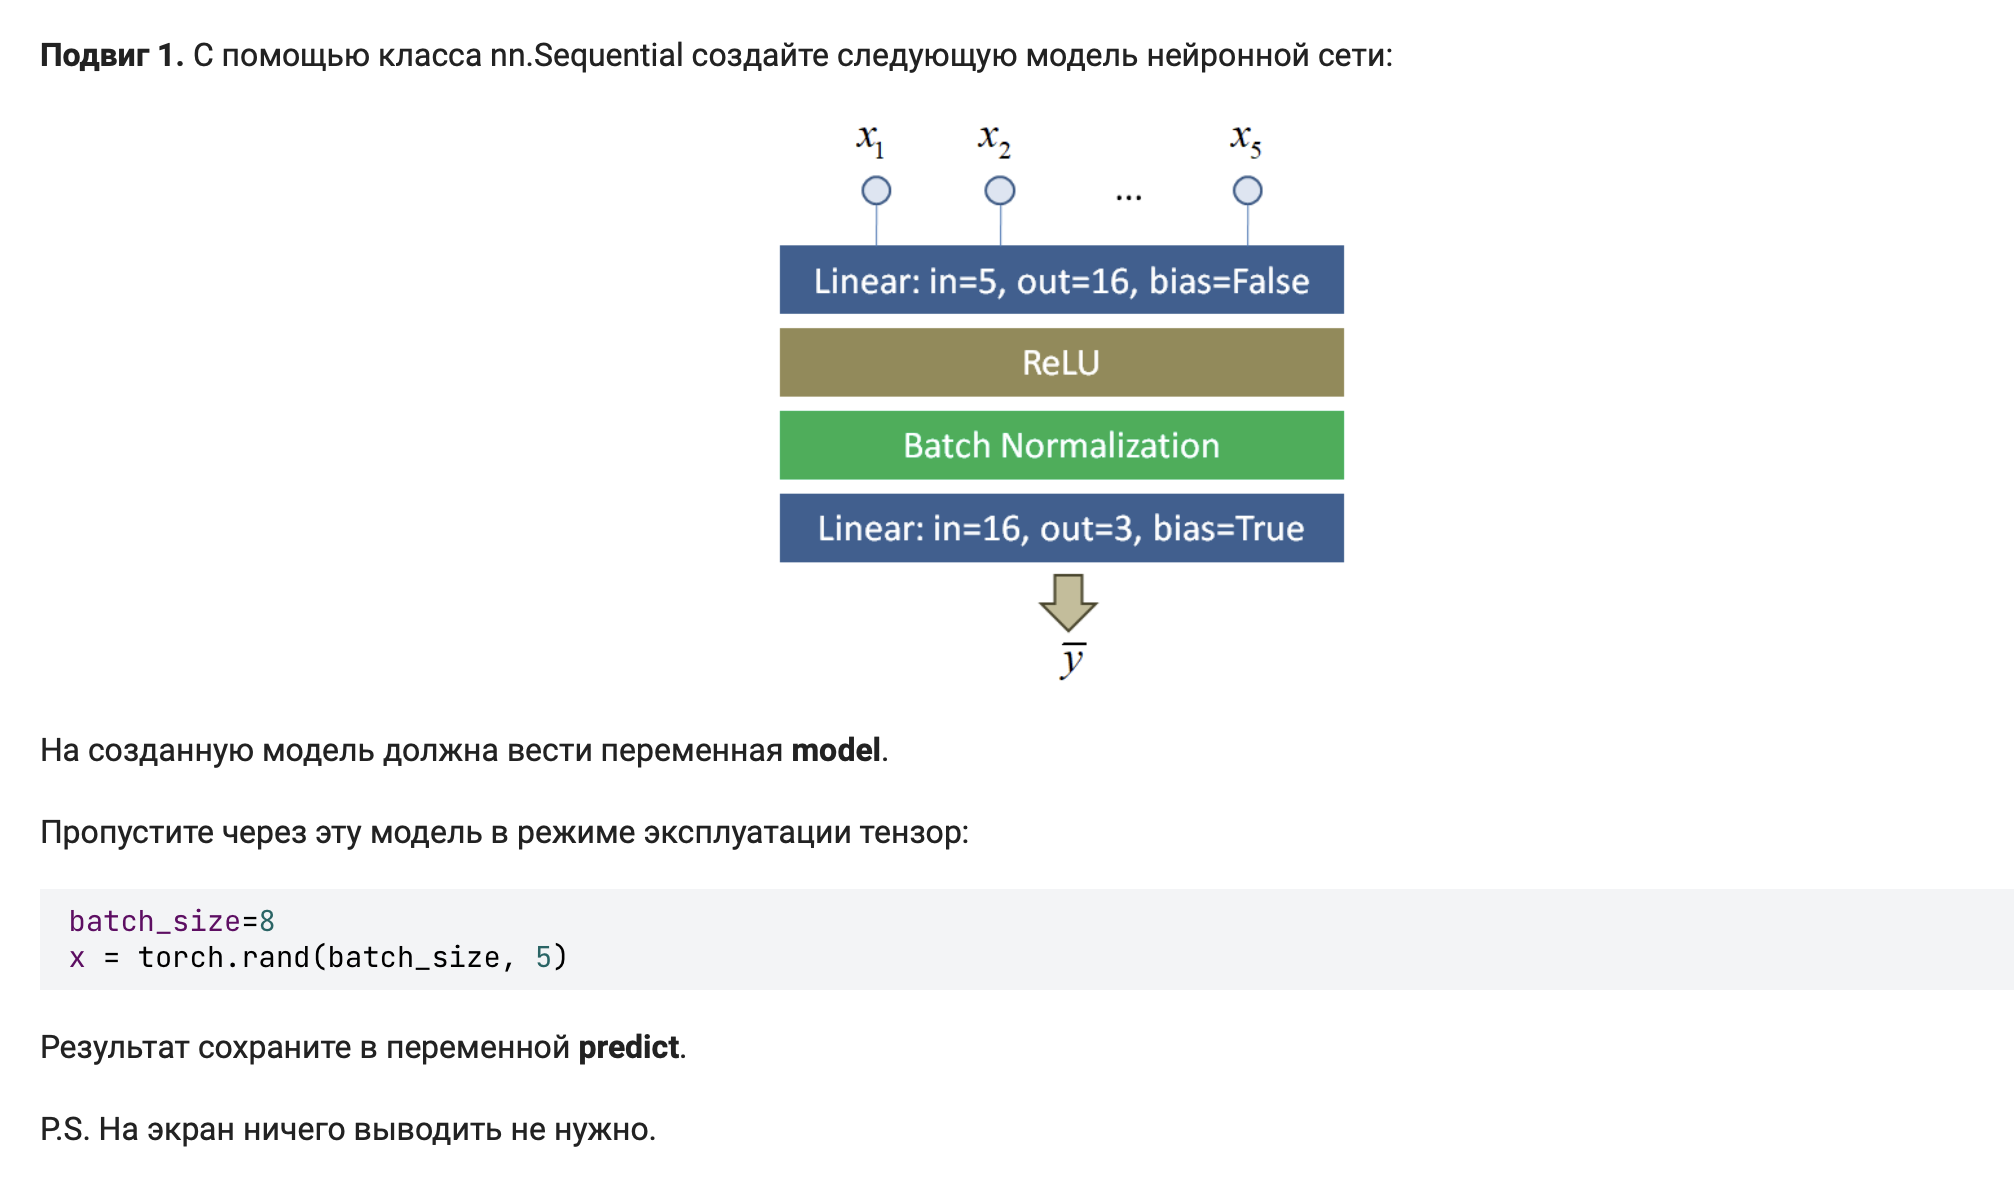

In [21]:
batch_size=8
x = torch.rand(batch_size, 5) # тензор x в программе не менять

# здесь продолжайте программу
model = nn.Sequential(
    nn.Linear(5, 16, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(16),
    nn.Linear(16, 3)
)

model.eval()
predict = model(x)

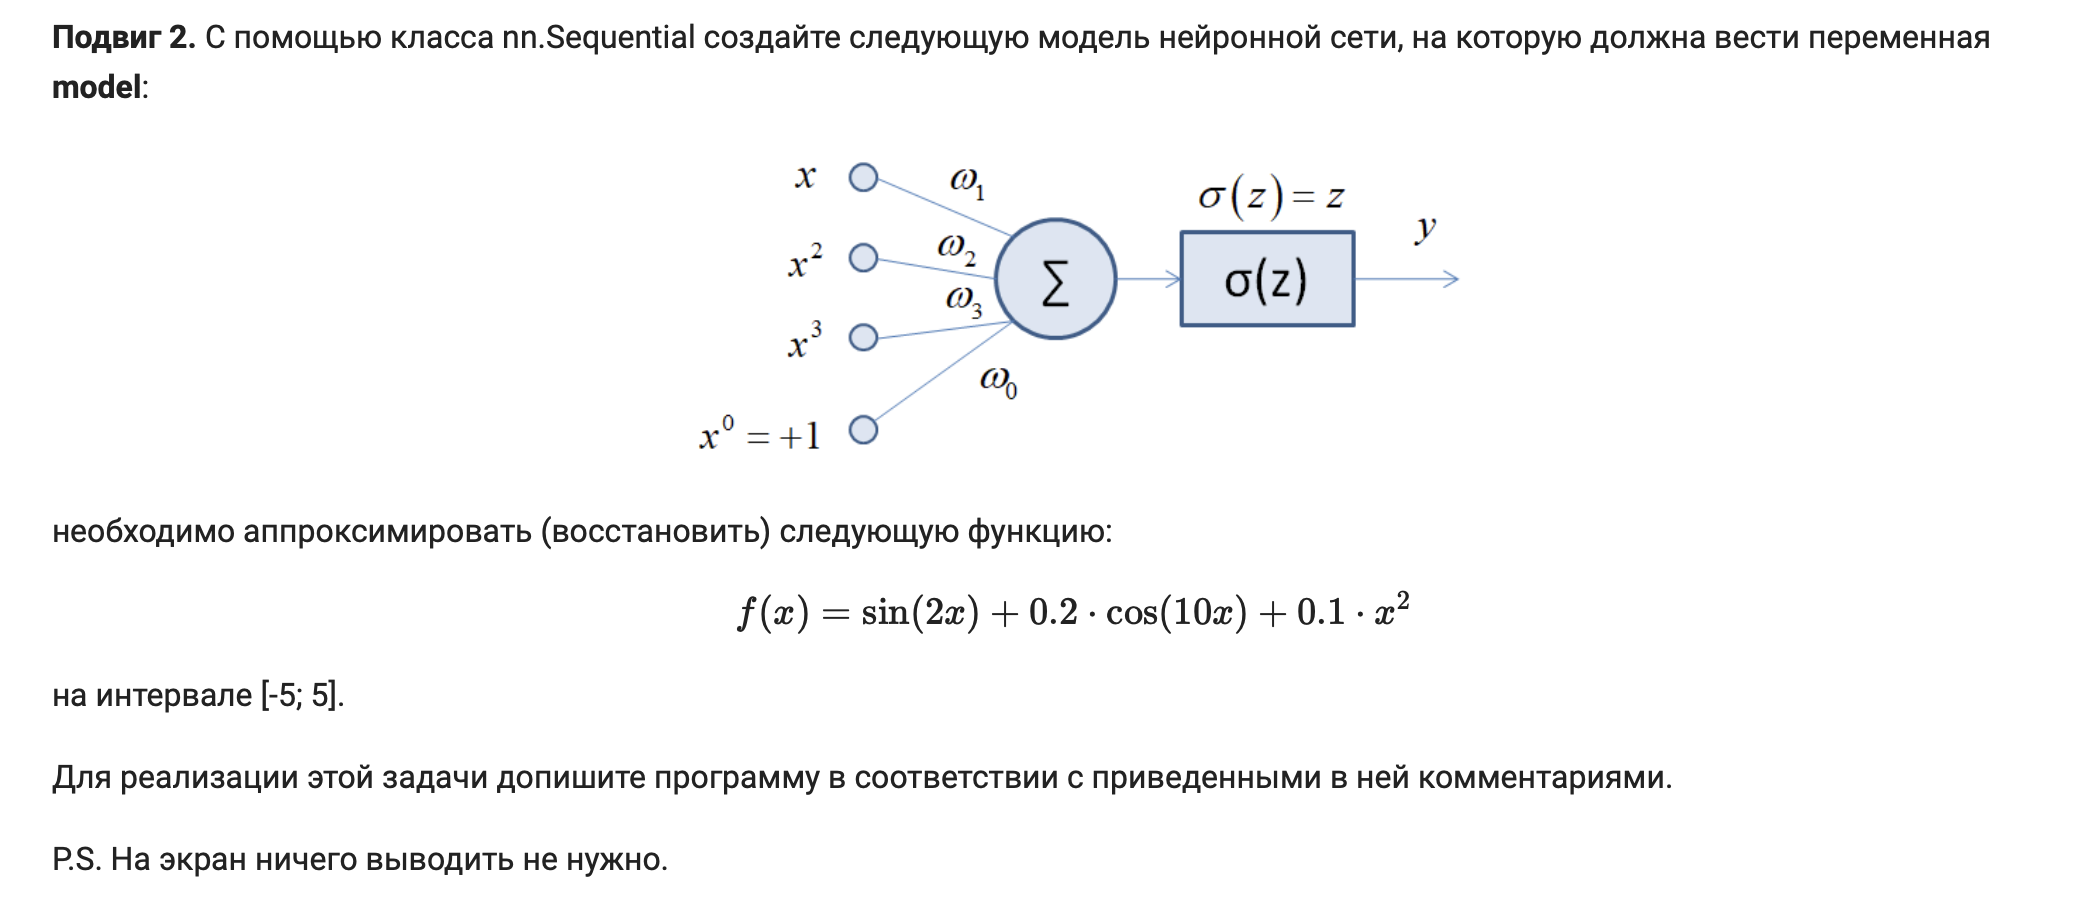

In [27]:
model = nn.Sequential(nn.Linear(3, 1)) # пропишите модель нейронной сети

# создание обучающей выборки
_x = torch.arange(-5, 5, 0.1)
data_y = torch.sin(2 * _x) + 0.2 * torch.cos(10 * _x) + 0.1 * _x ** 2

_x.unsqueeze_(-1)
data_x = torch.cat([_x, _x ** 2, _x ** 3], dim=1)
ds = data.TensorDataset(data_x, data_y)

epochs = 20 # число эпох обучения
batch_size = 8 # размер батча

train_data = data.DataLoader(ds, batch_size, shuffle=True) # создать объект класса DataLoader для датасета ds с размером пакетов batch_size и перемешиванием образов выборки

optimizer = optim.RMSprop(model.parameters(), lr=0.01) # создать оптимизатор RMSprop для обучения модели с шагом обучения 0.01
loss_func = nn.MSELoss() # создать функцию потерь с помощью класса MSELoss


# перевести модель в режим обучения
for _e in range(epochs): # итерации по эпохам
    for x_train, y_train in train_data:
        predict = model(x_train) # вычислить прогноз модели для данных x_train
        loss = loss_func(predict.squeeze(), y_train) # вычислить значение функции потерь

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# перевести модель в режим эксплуатации
model.eval()
# выполнить прогноз модели по всем данным выборки (d_train.data)
pred = model(data_x)
# вычислить потери с помощью loss_func по всем данным выборки; значение Q сохранить в виде вещественного числа
Q = loss_func(pred.squeeze(), data_y).item()
Q

0.5333327651023865

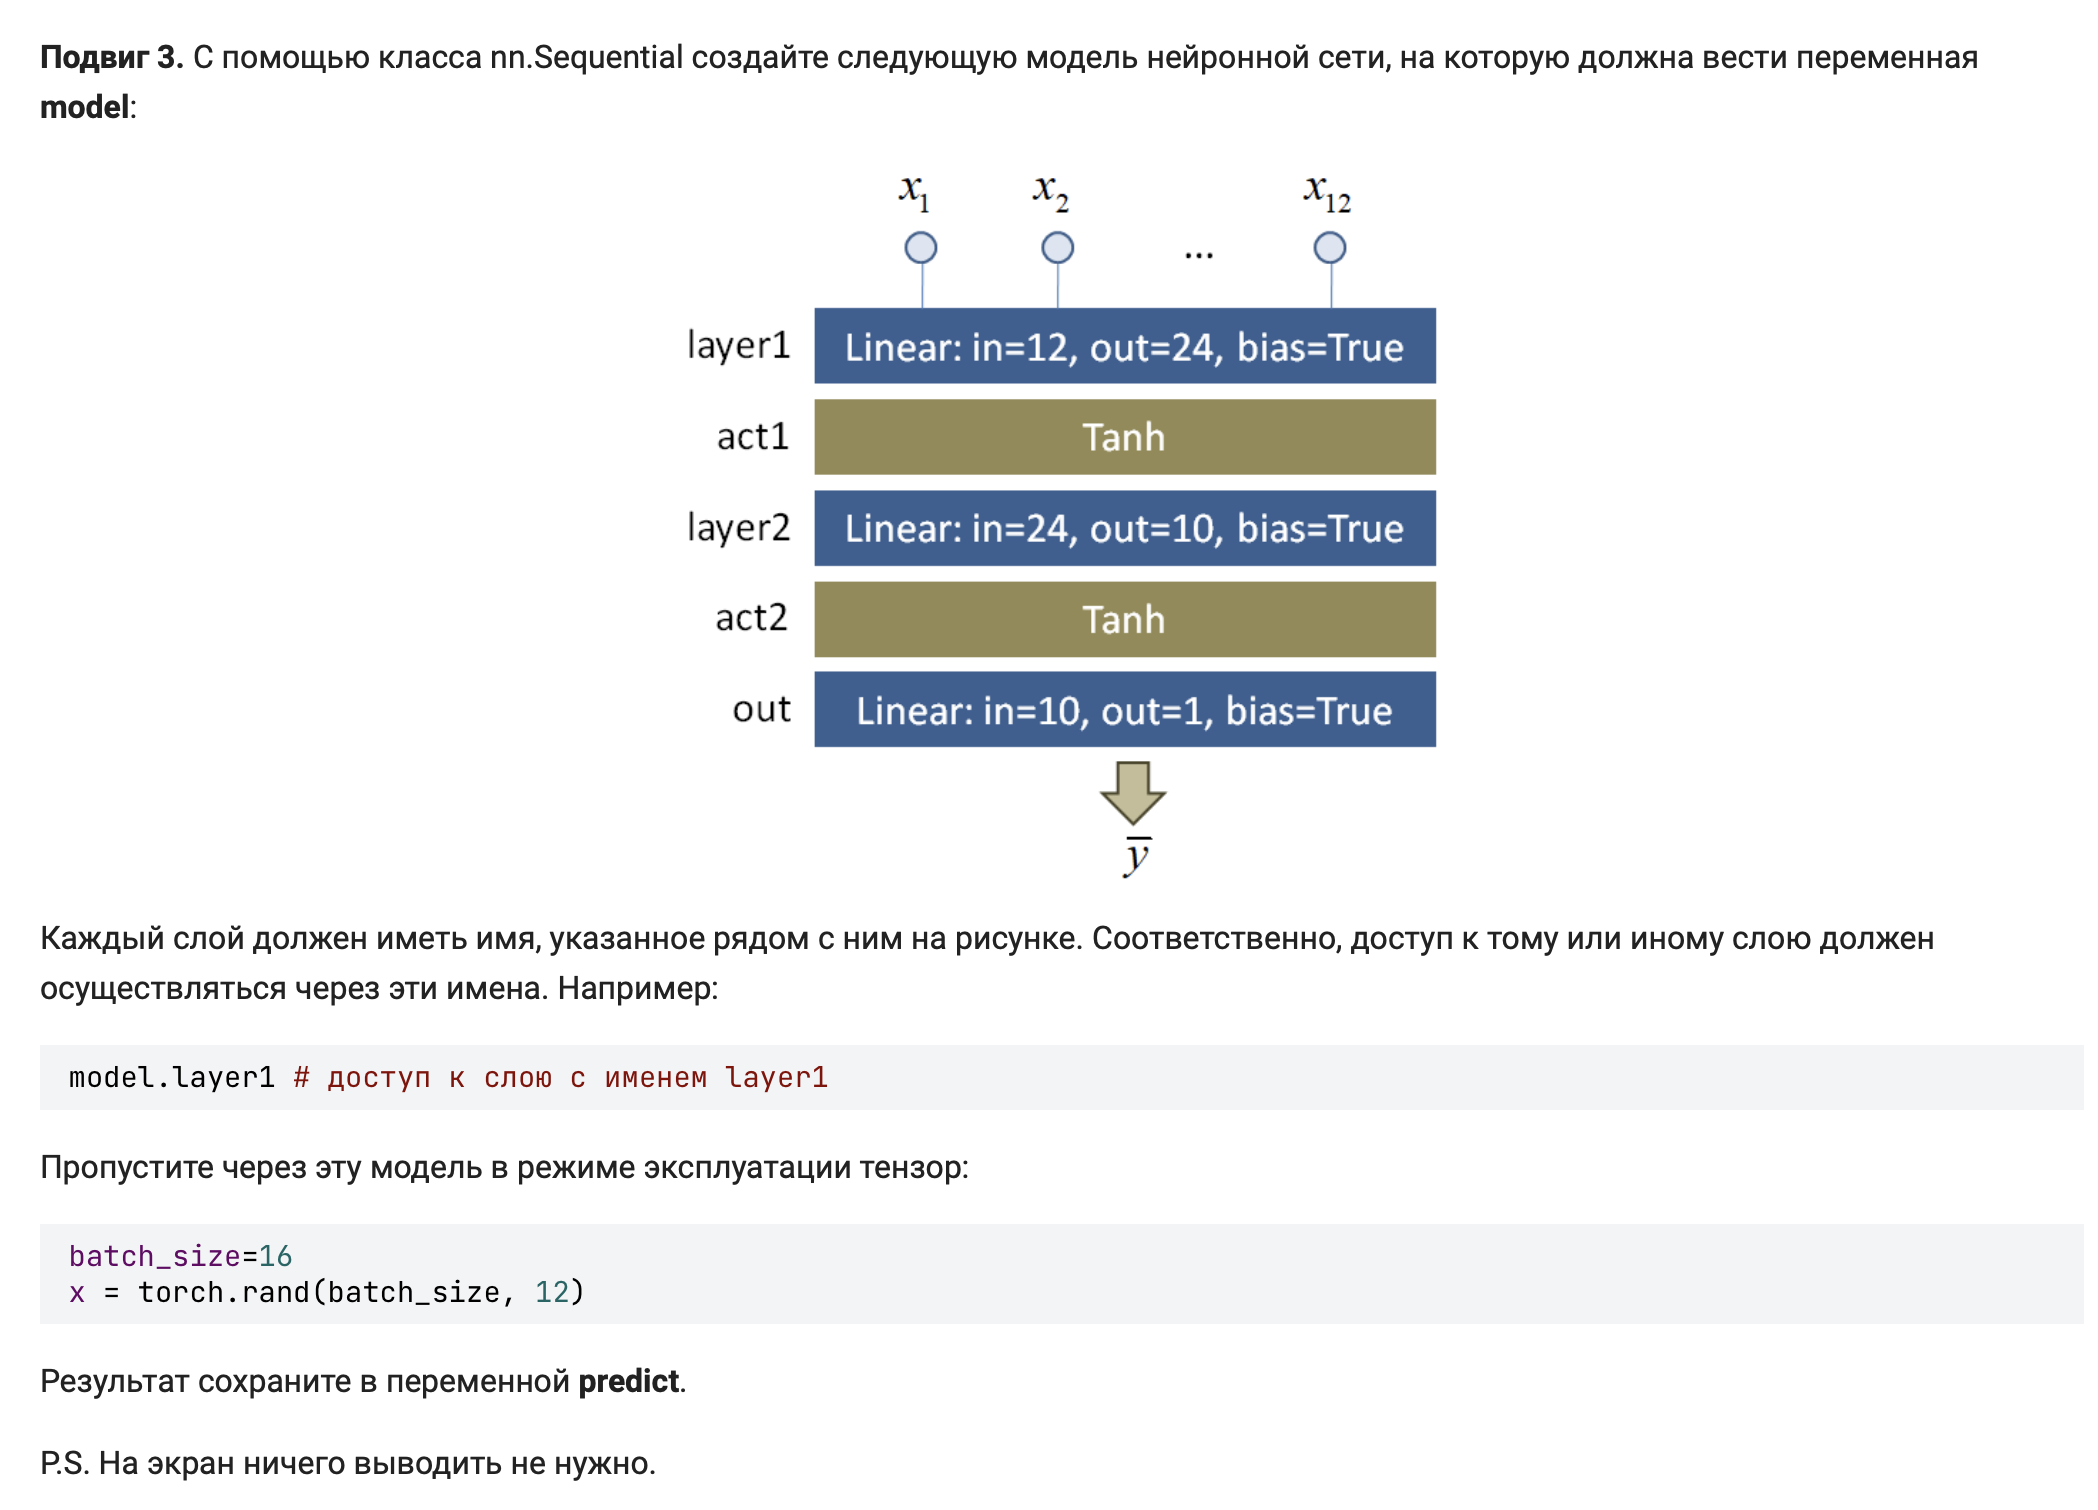

In [ ]:
batch_size=16
x = torch.rand(batch_size, 12) # тензор x в программе не менять

# здесь продолжайте программу
model = nn.Sequential()
model.add_module('layer1', nn.Linear(12, 24))
model.add_module('act1', nn.Tanh())
model.add_module('layer2', nn.Linear(24, 10))
model.add_module('act2', nn.Tanh())
model.add_module('out', nn.Linear(10, 1))

model.eval()
predict = model(x)

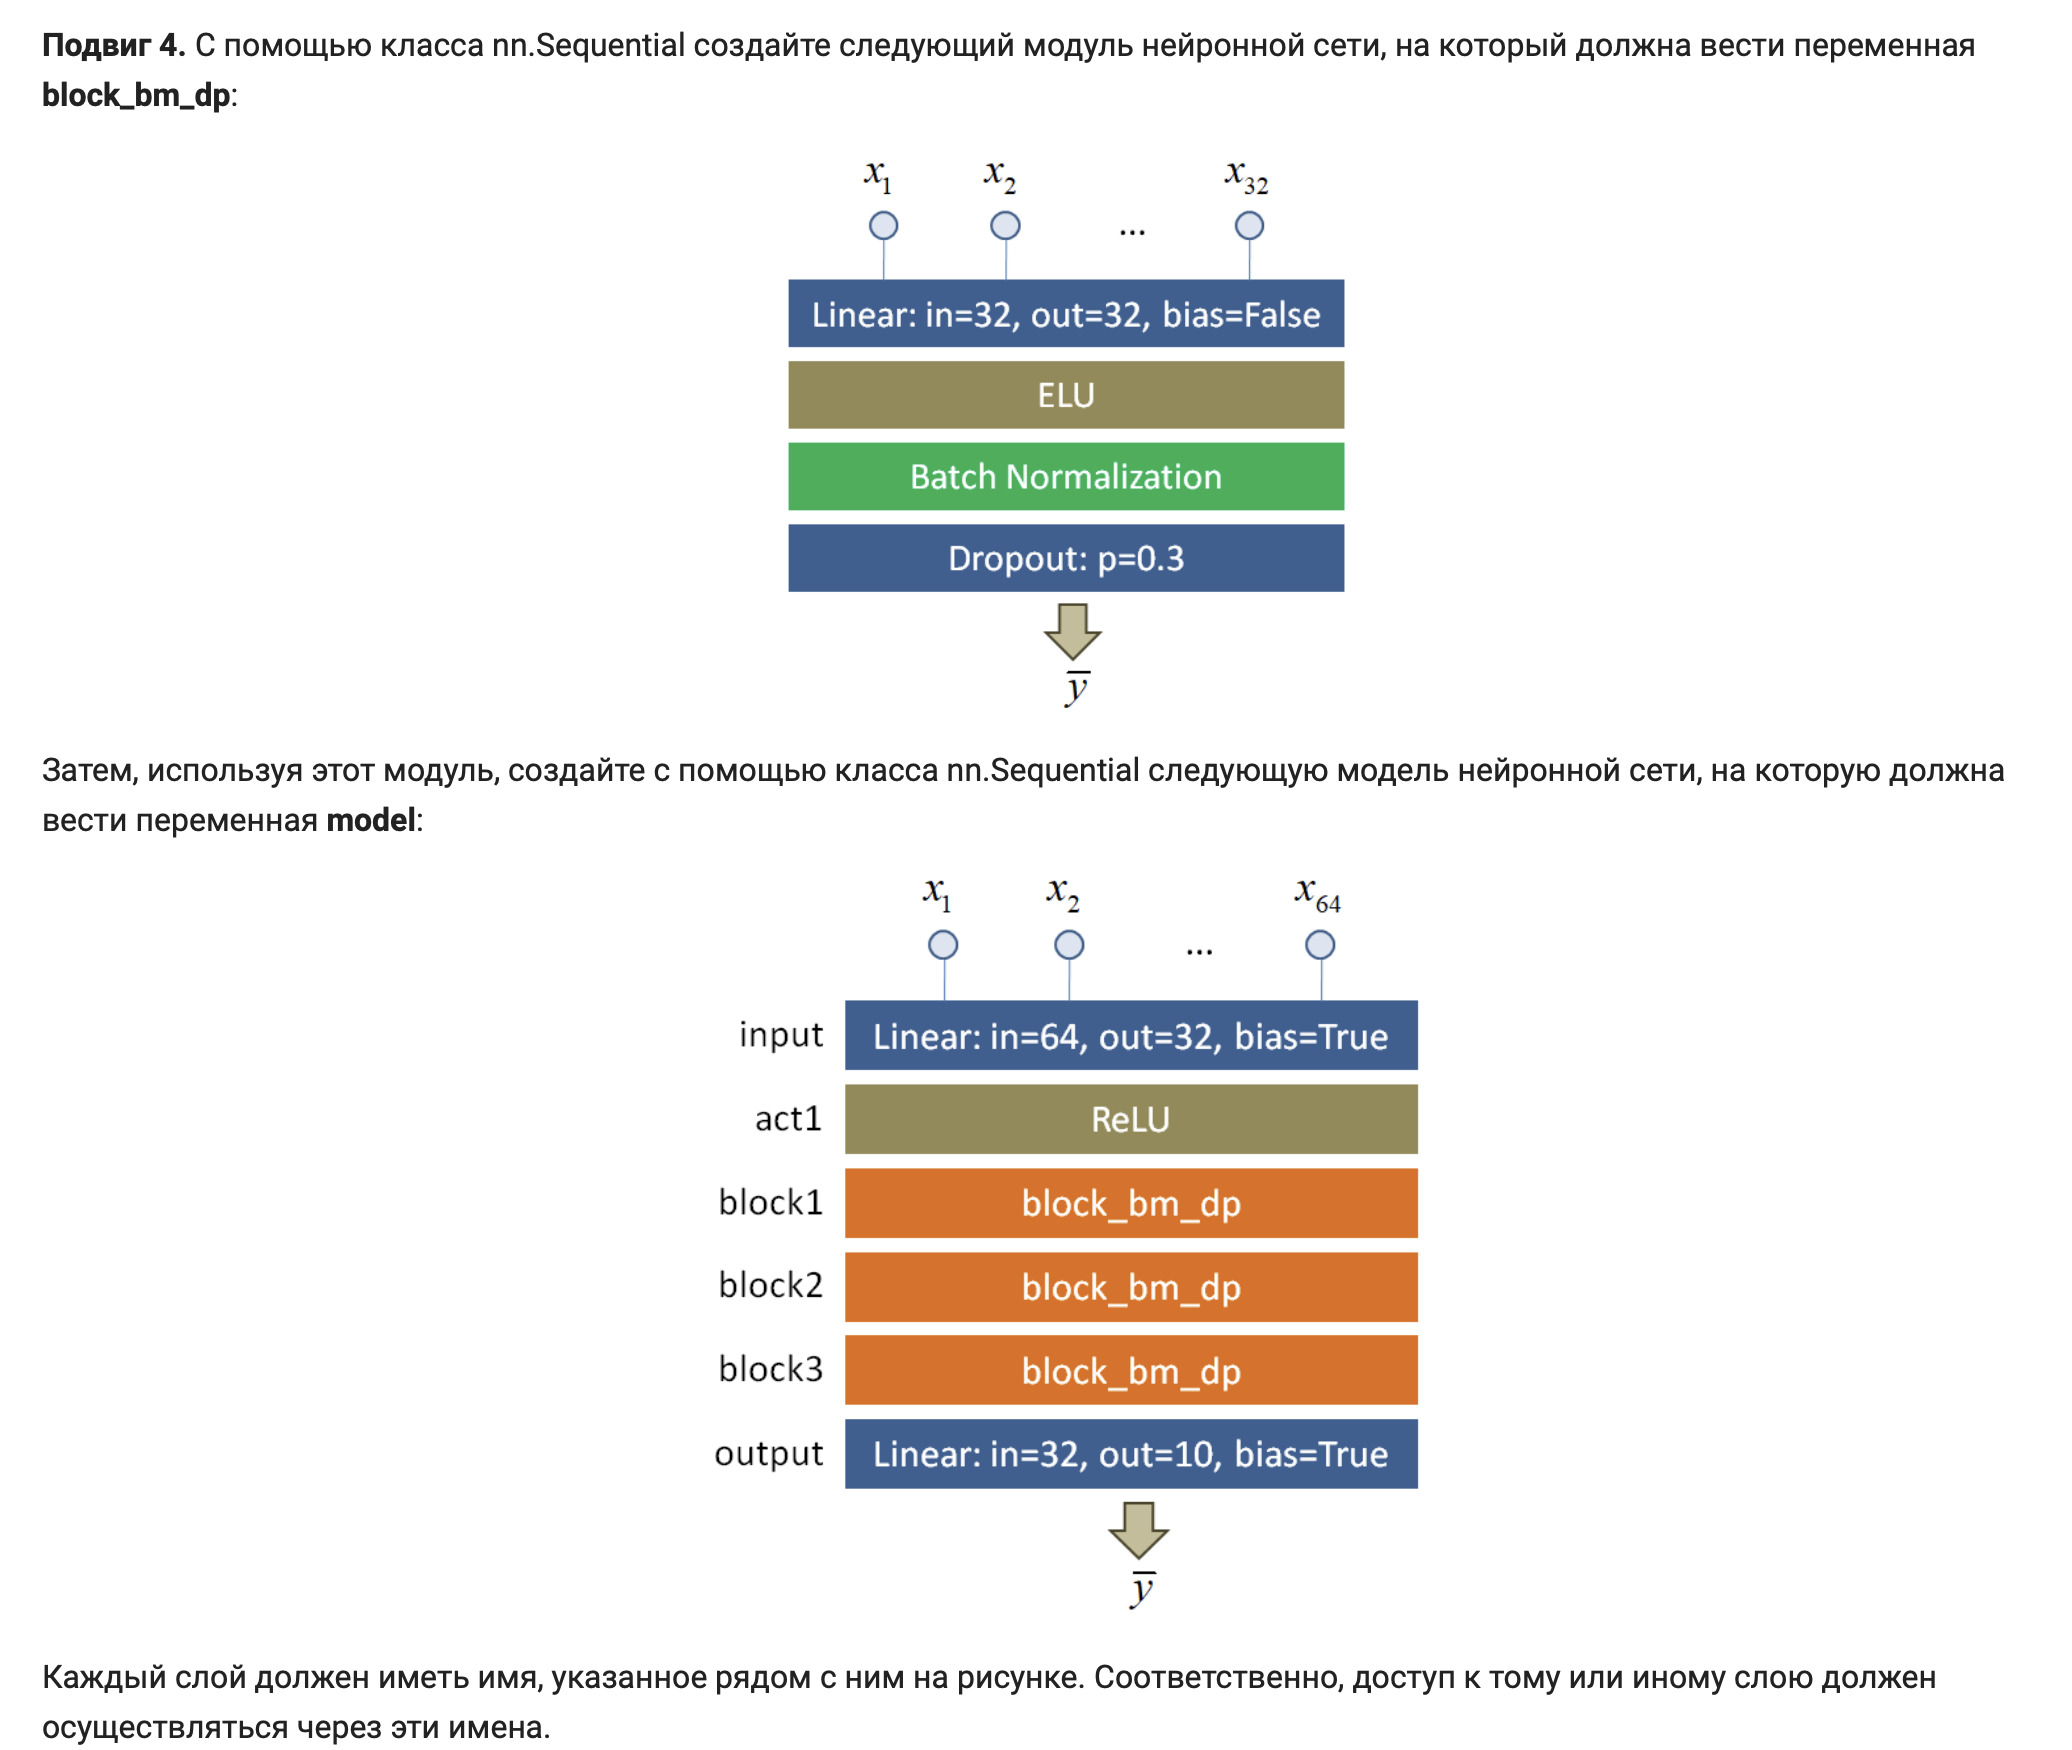
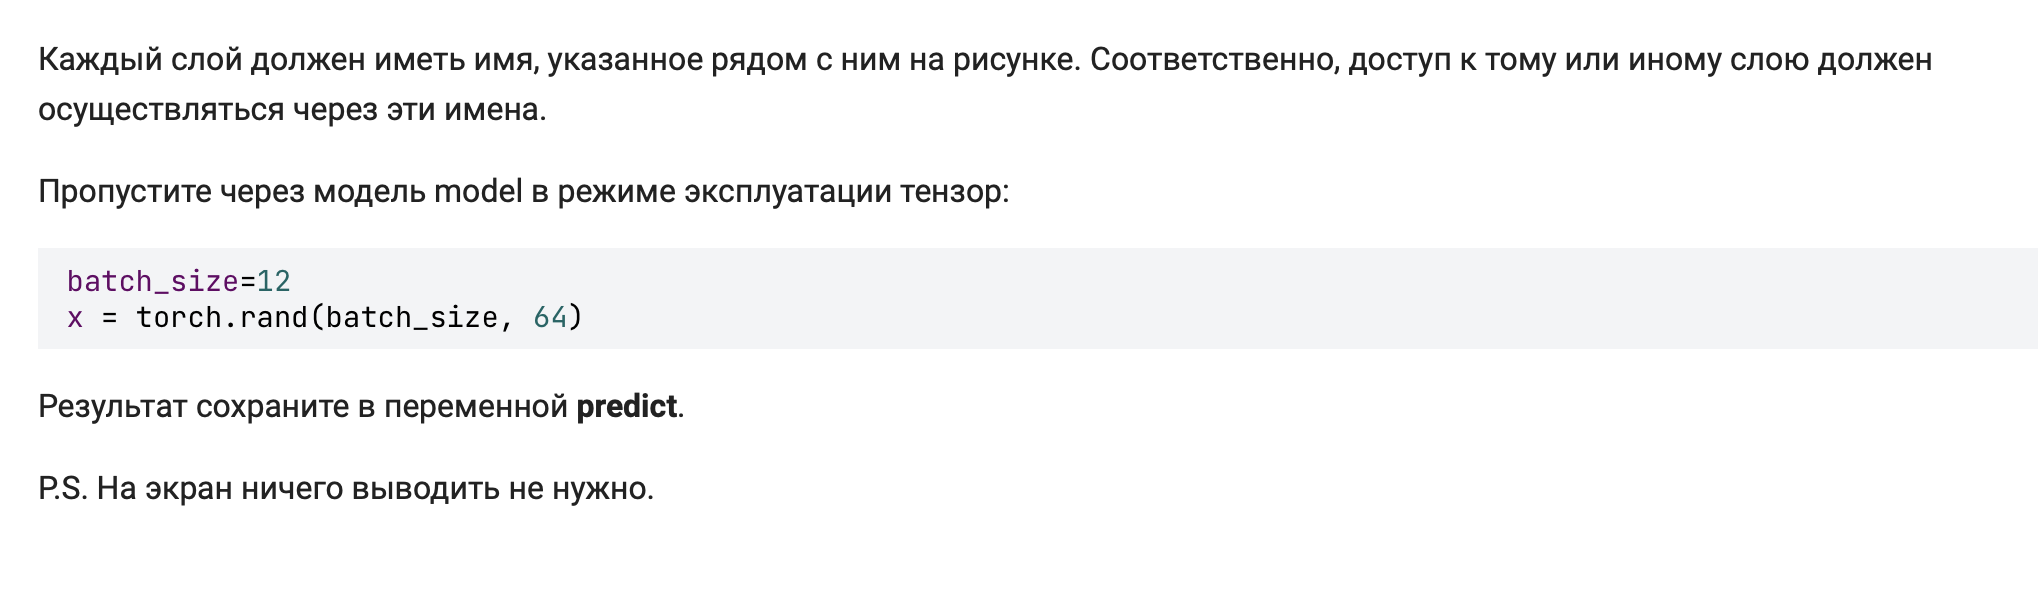

In [ ]:
batch_size=12
x = torch.rand(batch_size, 64) # тензор x в программе не менять

# здесь продолжайте программу
block_bm_dp = nn.Sequential(
    nn.Linear(32, 32, bias=False),
    nn.ELU(),
    nn.BatchNorm1d(32),
    nn.Dropout(0.3)
)

model = nn.Sequential()
model.add_module('input', nn.Linear(64, 32))
model.add_module('act1', nn.ReLU())
model.add_module('block1', block_bm_dp)
model.add_module('block2', block_bm_dp)
model.add_module('block3', block_bm_dp)
model.add_module('output', nn.Linear(32, 10))

predict = model(x)

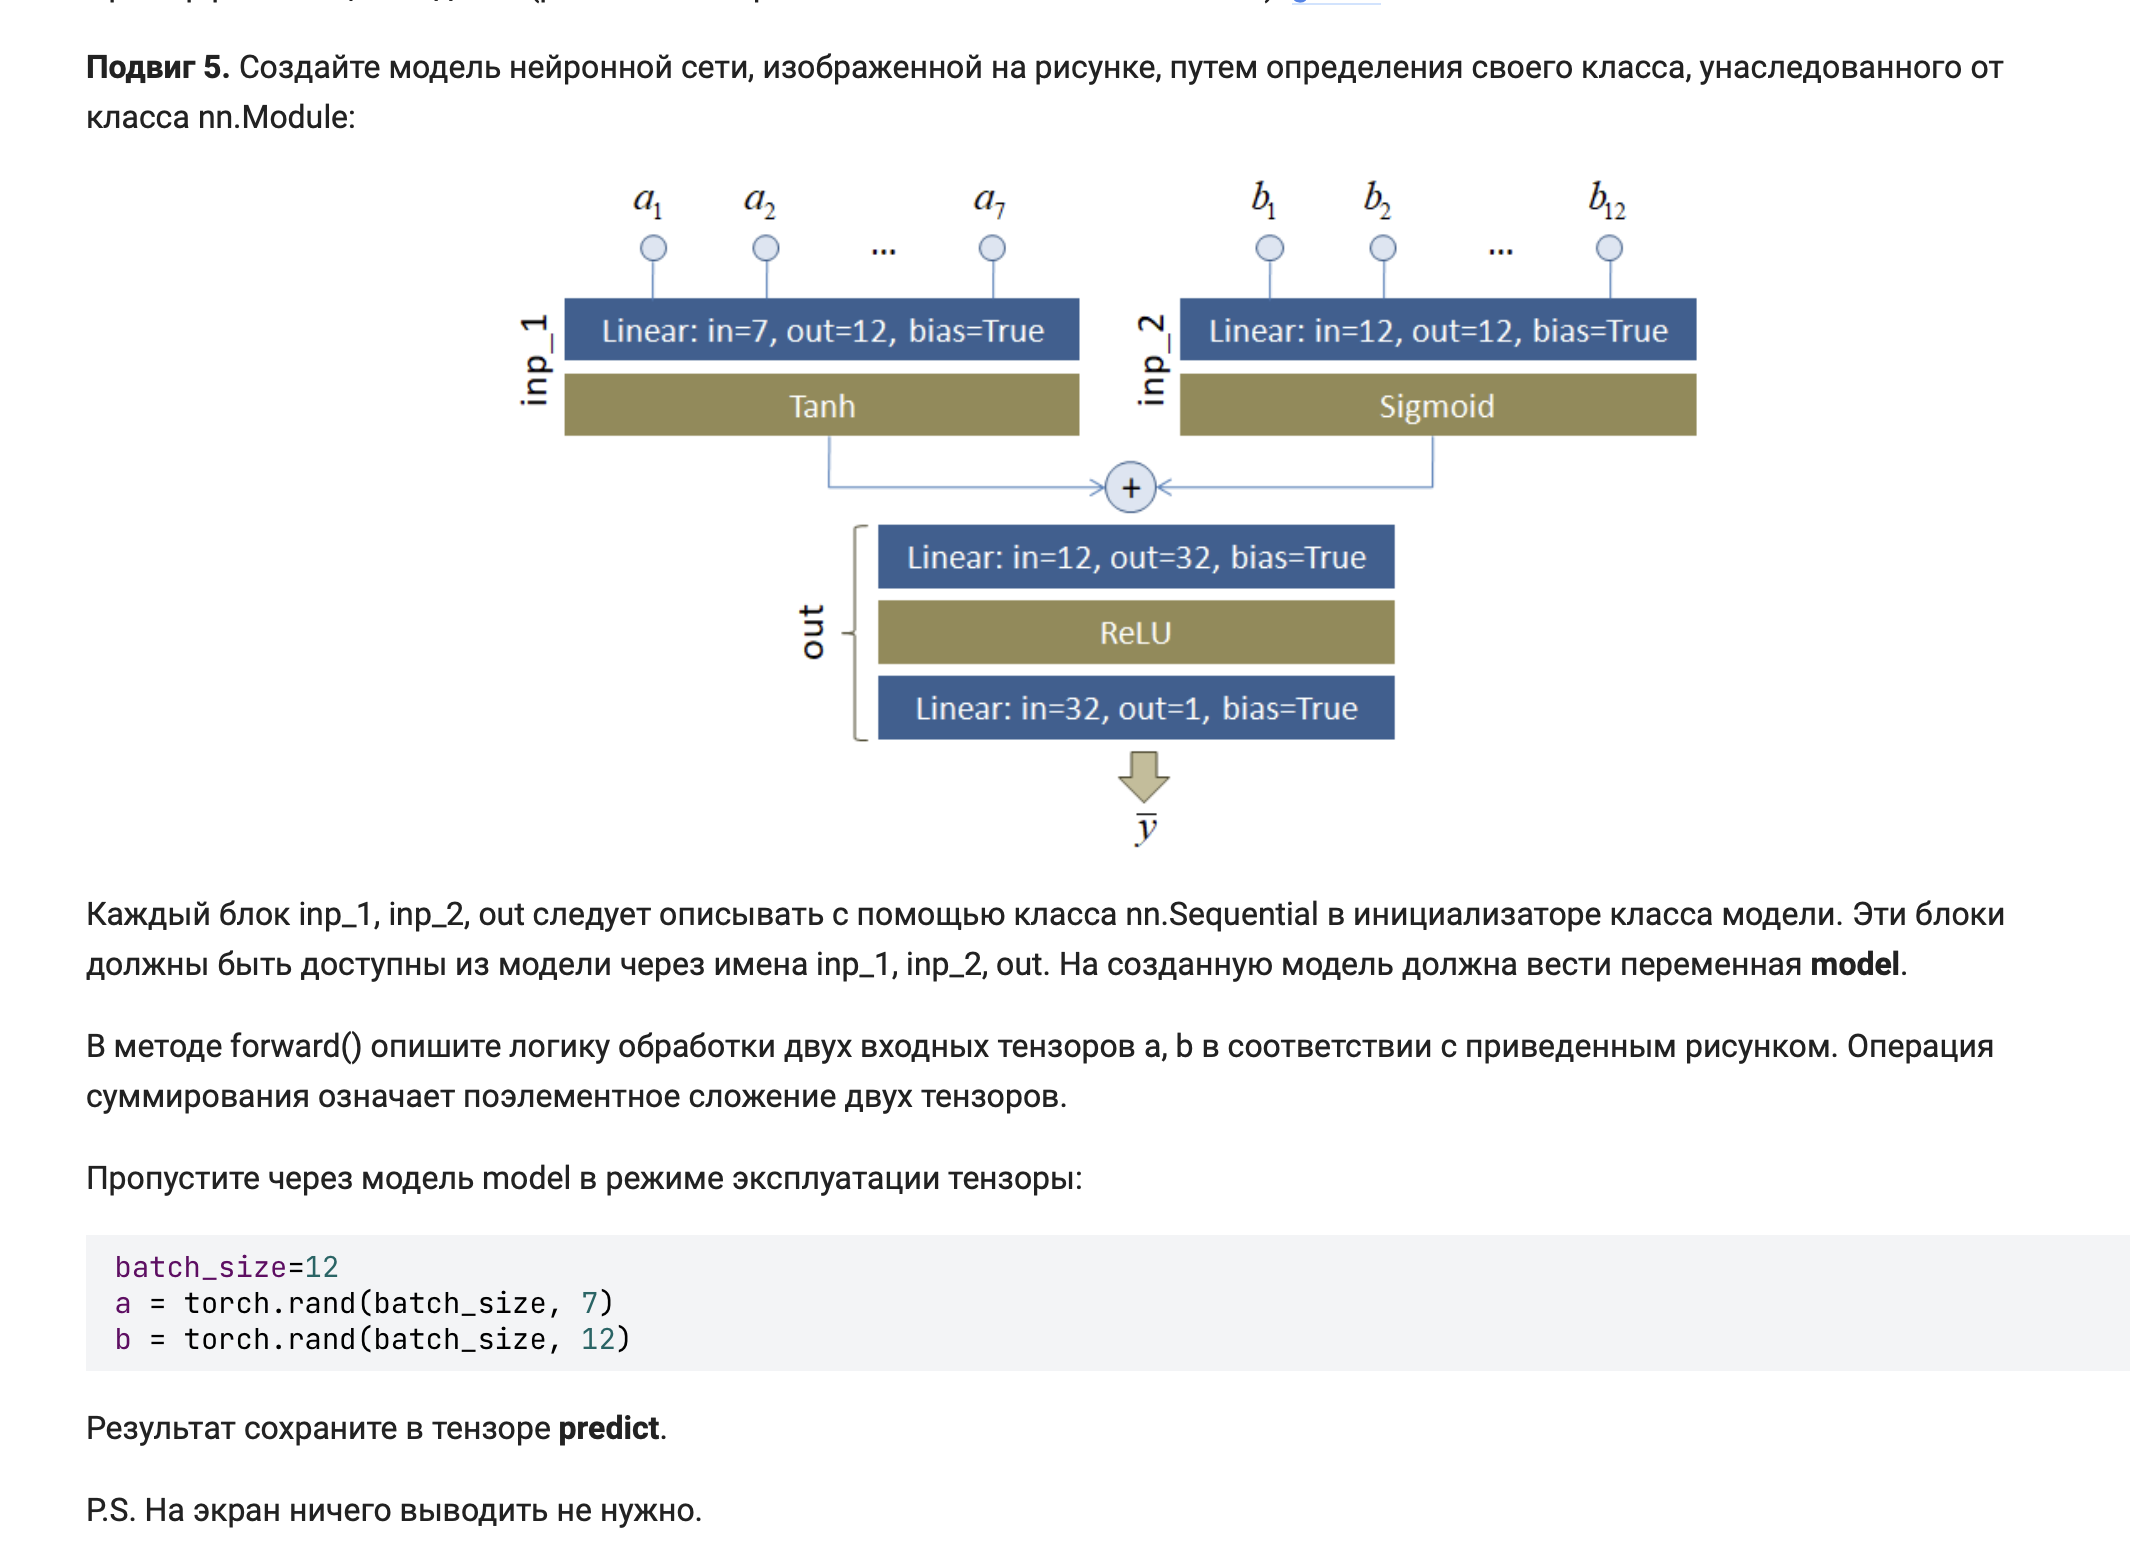

In [32]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp_1 = nn.Sequential(
            nn.Linear(7, 12),
            nn.Tanh()
        )
        self.inp_2 = nn.Sequential(
            nn.Linear(12, 12),
            nn.Sigmoid()
        )
        self.out = nn.Sequential(
            nn.Linear(12, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, a, b):
        x1 = self.inp_1(a)
        x2 = self.inp_2(b)
        x = x1 + x2
        x = self.out(x)

        return x
    
batch_size=12
a = torch.rand(batch_size, 7) # тензоры a, b в программе не менять
b = torch.rand(batch_size, 12)
    
model = Model()
model.eval()

predict = model(a, b)

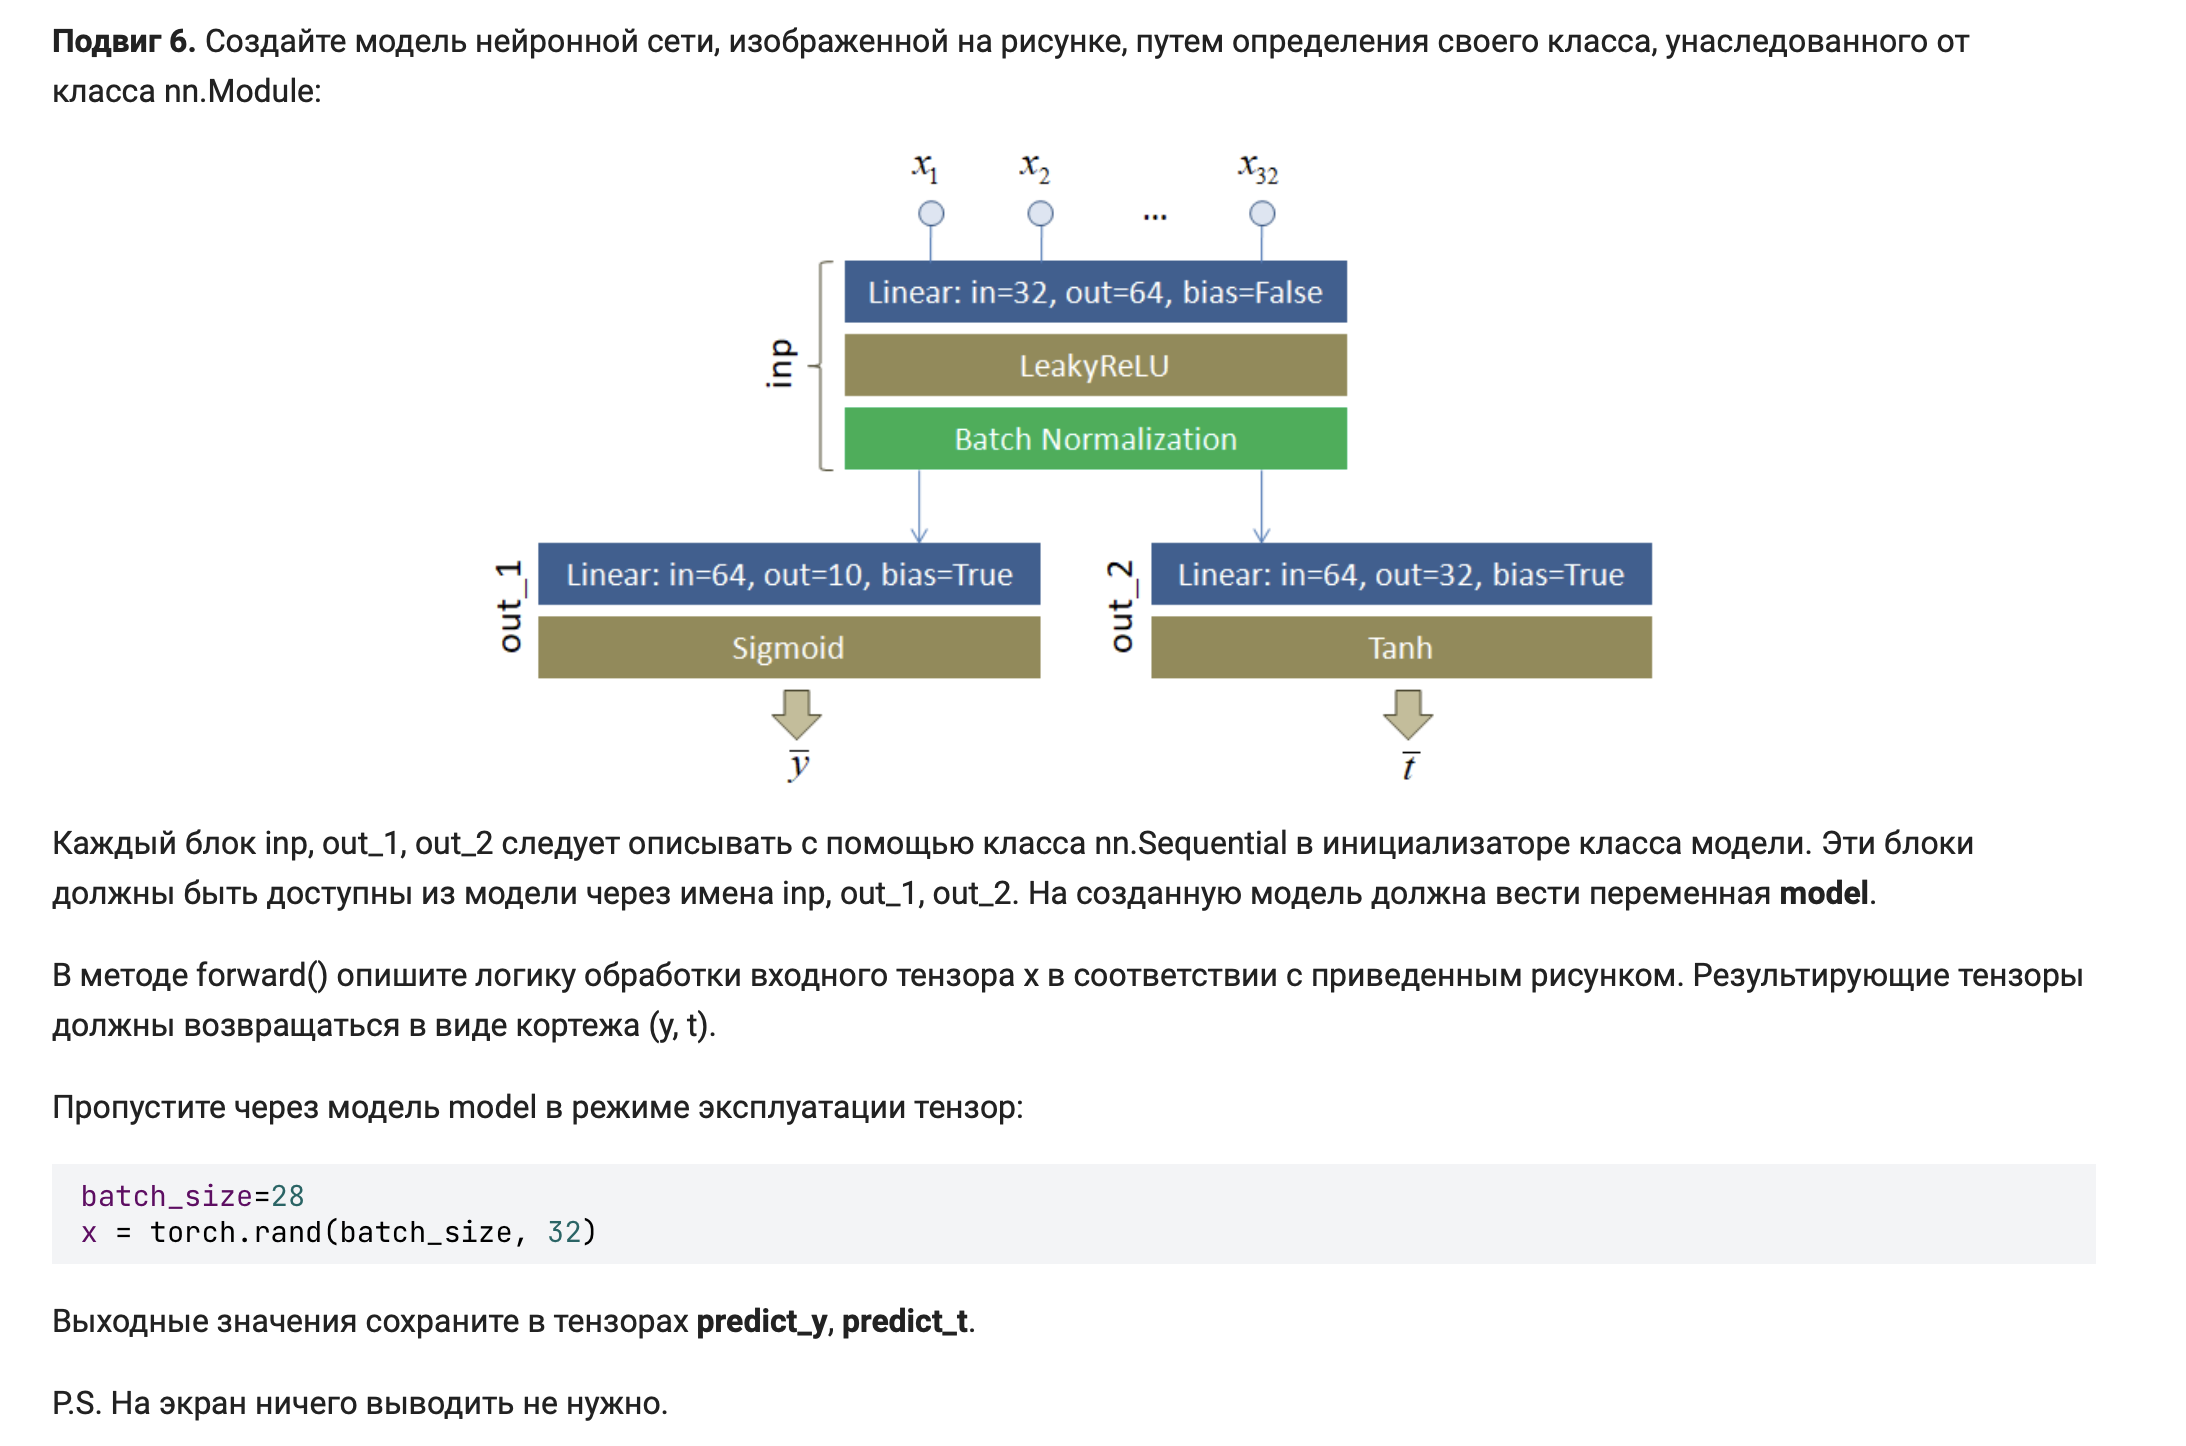

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(32, 64, bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm1d(64)
        )

        self.out_1 = nn.Sequential(
            nn.Linear(64, 10),
            nn.Sigmoid()
        )

        self.out_2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.inp(x)
        y = self.out_1(x)
        t = self.out_2(x)

        return y, t
    
batch_size=28
x = torch.rand(batch_size, 32) # тензор x в программе не менять
    
model = Model()
model.eval()
predict_y, predict_t = model(x)

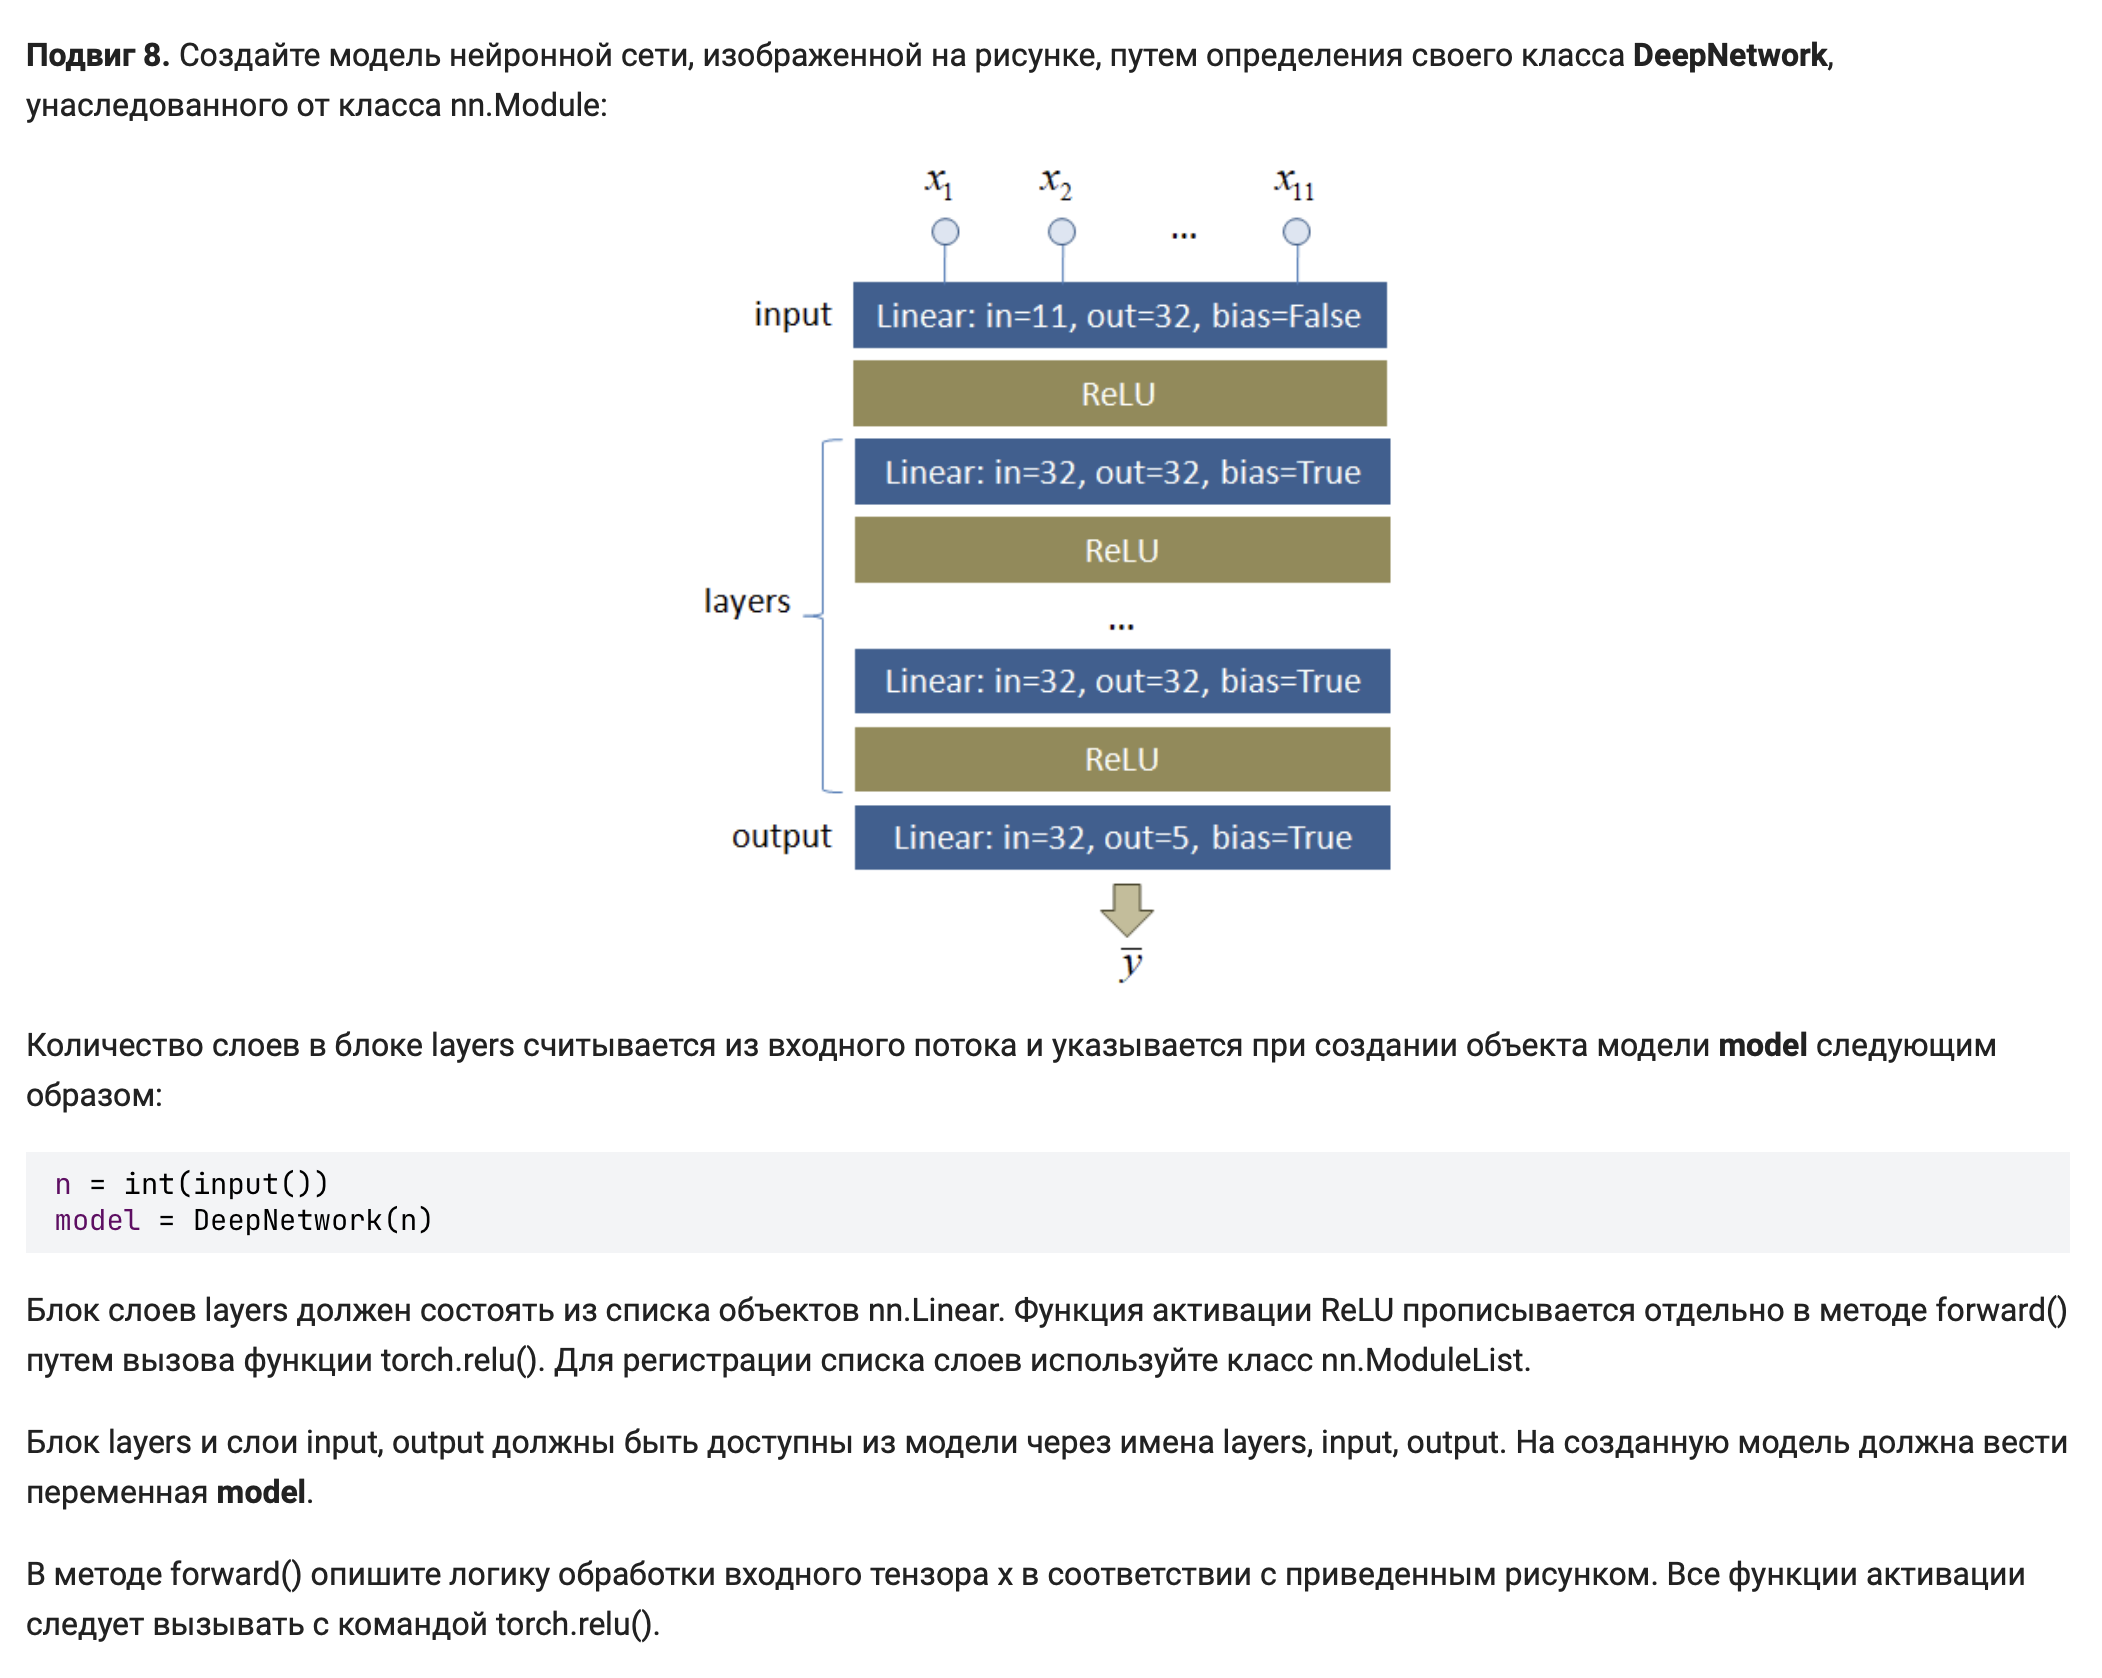
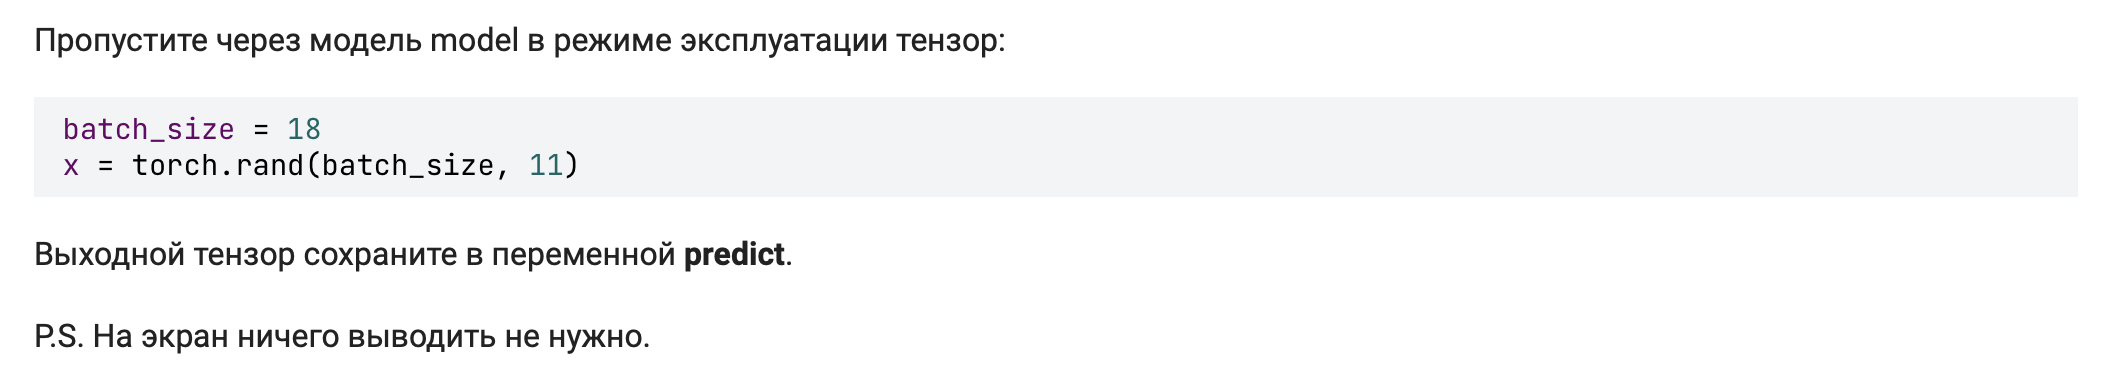


In [34]:
# здесь объявляйте класс модели
class DeepNetwork(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.input = nn.Linear(11, 32, bias=False)
        self.layers = nn.ModuleList([nn.Linear(32, 32) for _ in range(n)])
        self.output = nn.Linear(32, 5)

    def forward(self, x):
        x = self.input(x).relu()
        for layer in self.layers:
            x = layer(x).relu()
        x = self.output(x)
        return x
        

n = int(input()) # это значение в программе не менять

batch_size = 18
x = torch.rand(batch_size, 11) # тензор x в программе не менять

# здесь продолжайте программу
model = DeepNetwork(n)
model.eval()
predict = model(x)

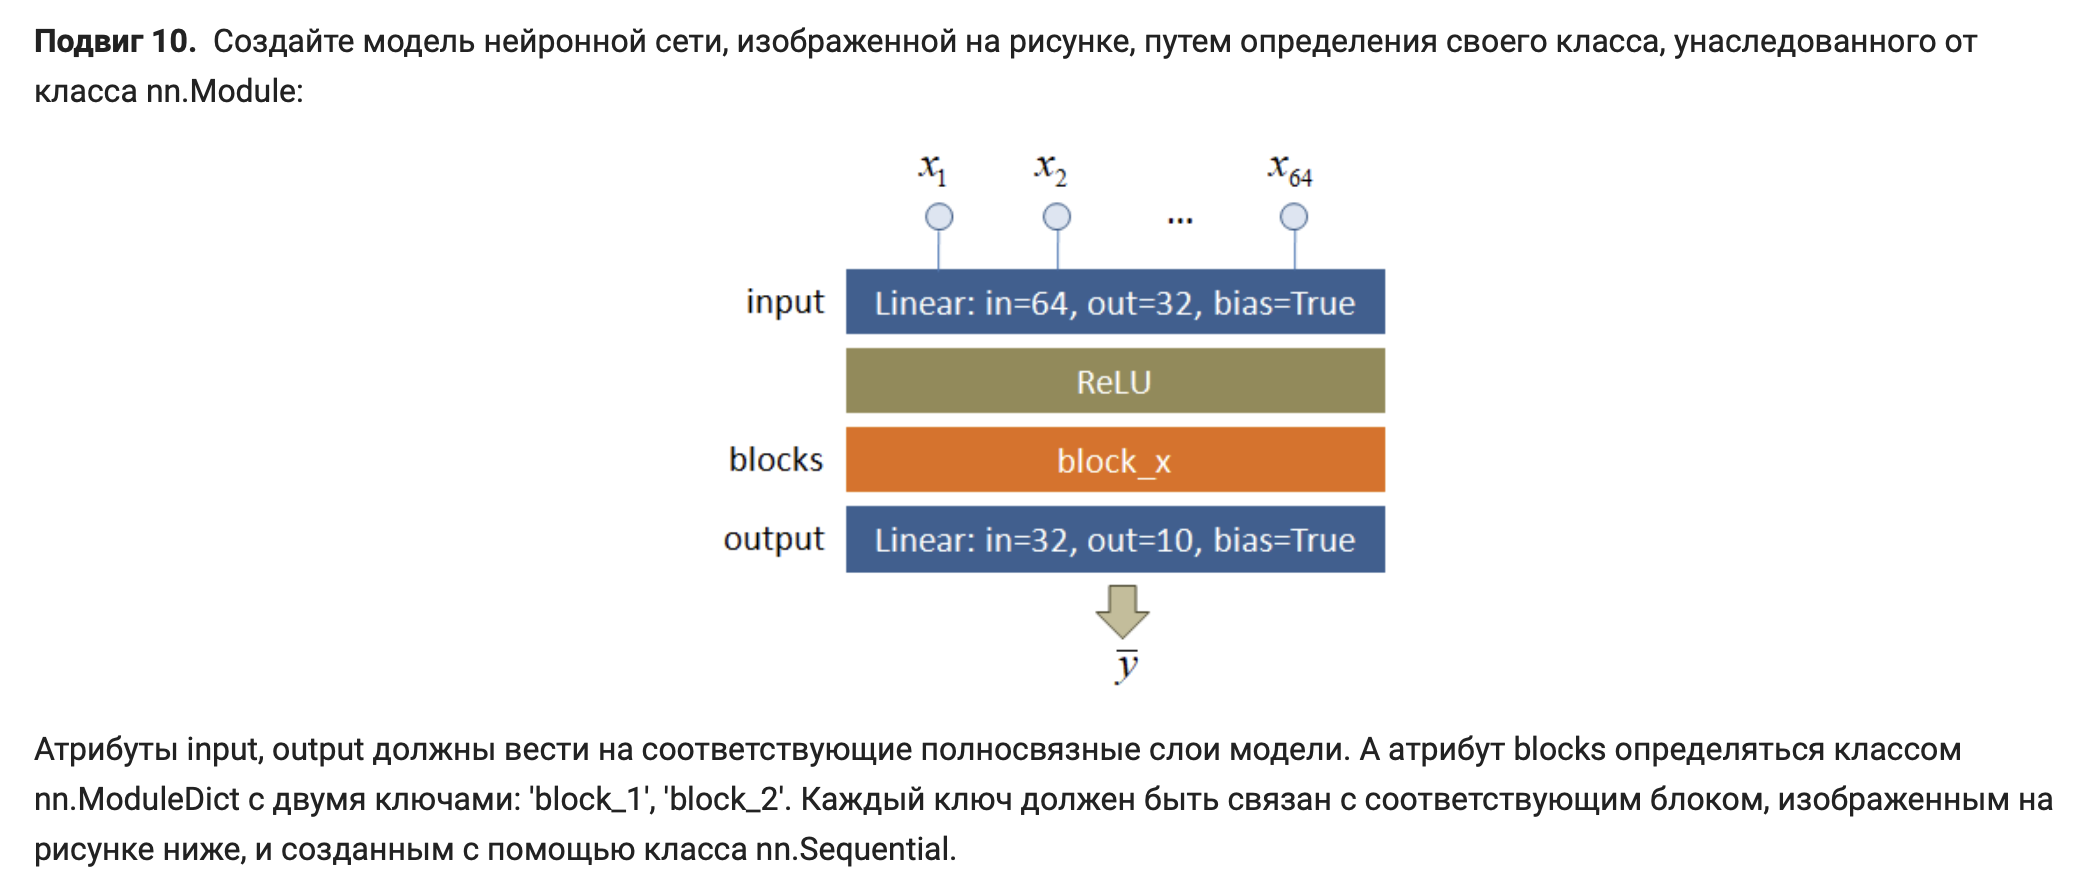
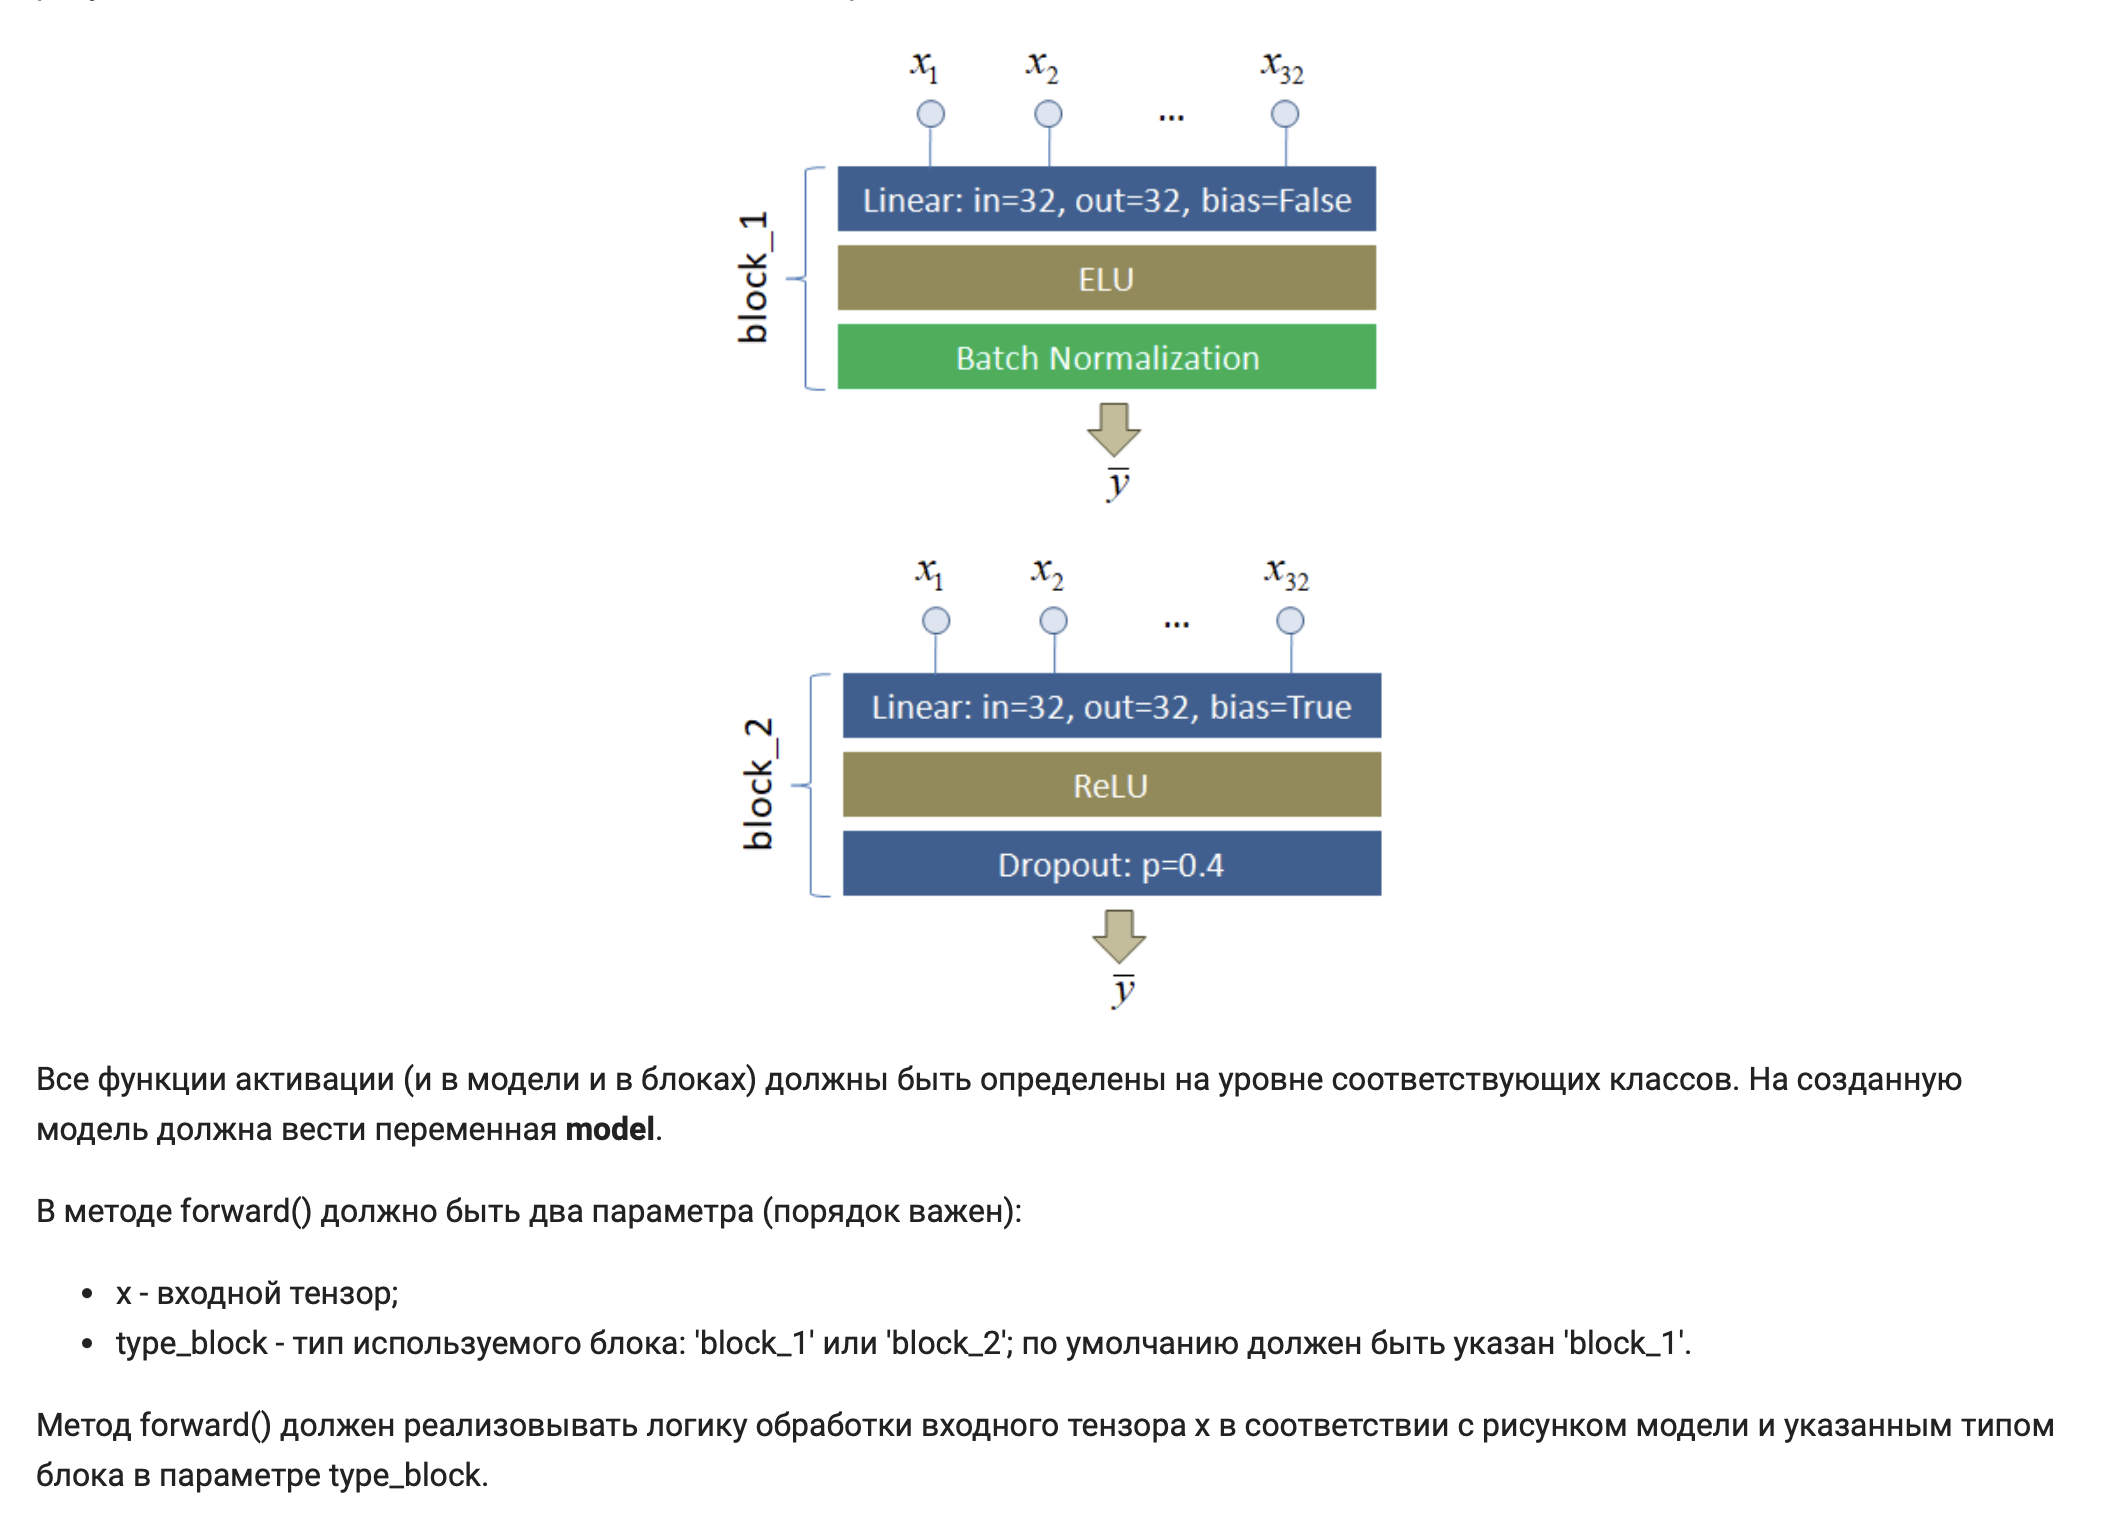
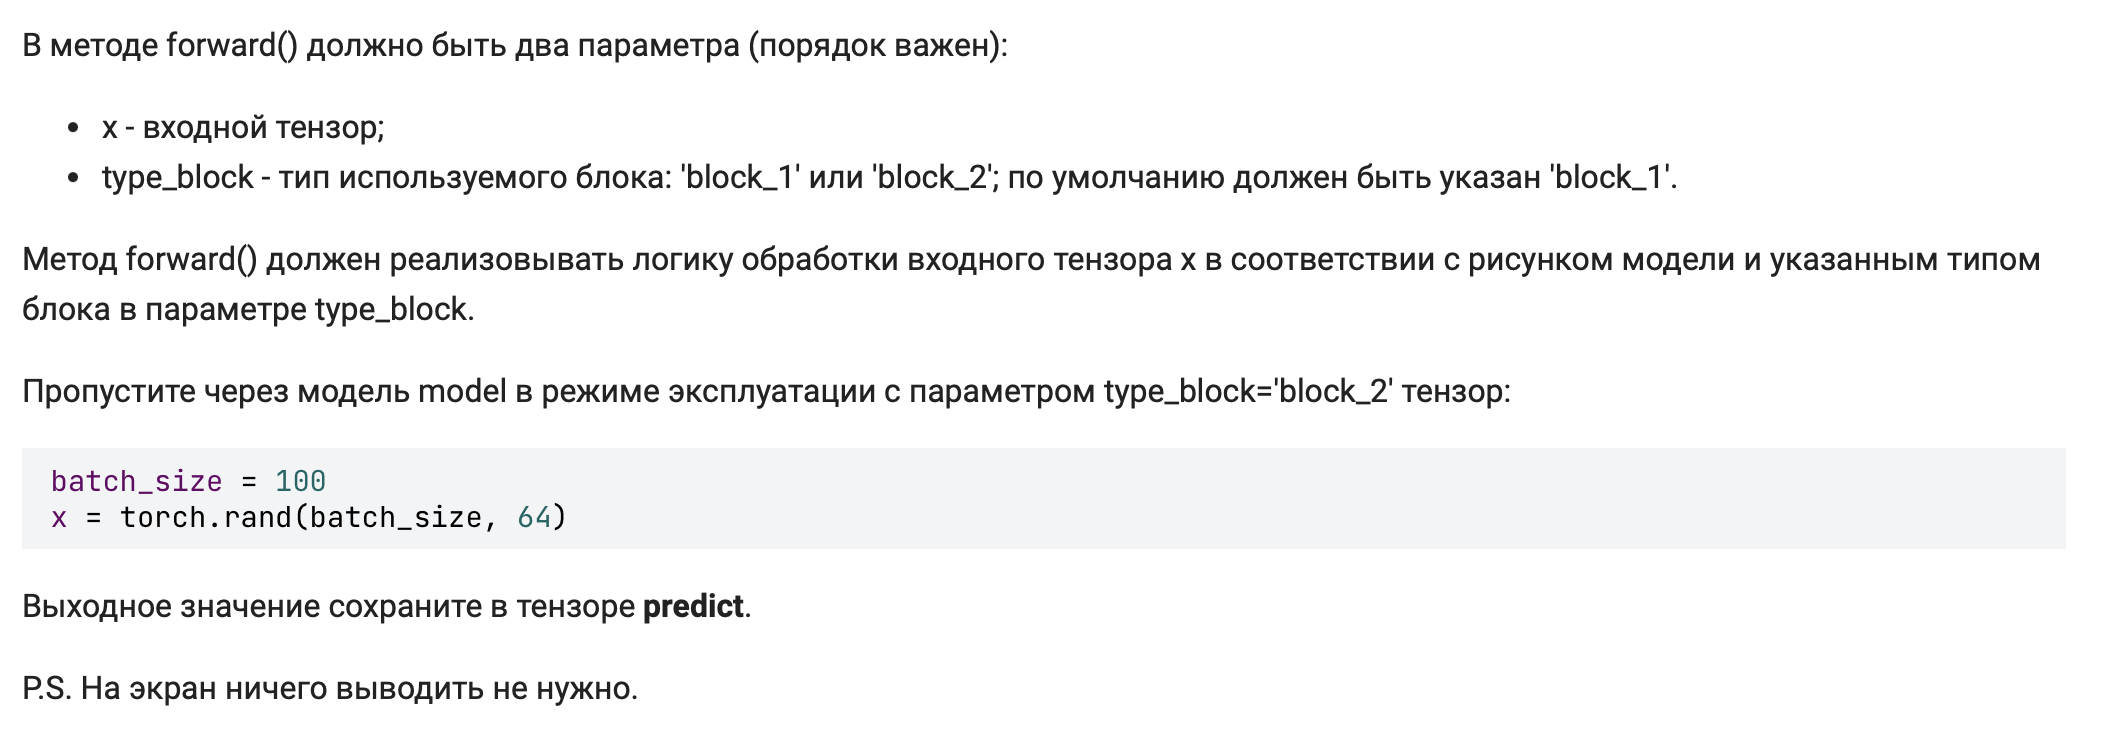

In [35]:
# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        bl1 = nn.Sequential(
            nn.Linear(32, 32, bias=False),
            nn.ELU(),
            nn.BatchNorm1d(32)
        )
        bl2 = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        self.input = nn.Linear(64, 32)
        self.blocks = nn.ModuleDict({
            'block_1': bl1,
            'block_2': bl2
        })
        self.output = nn.Linear(32, 10)

    def forward(self, x, type_block='block_1'):
        x = self.input(x).relu()
        x = self.blocks[type_block](x) if type_block in self.blocks.keys() else self.blocks['block_1'](x)
        x = self.output(x)

        return x

batch_size = 100
x = torch.rand(batch_size, 64) # тензор x в программе не менять

# здесь продолжайте программу
model = Model()
model.eval()
predict = model(x, 'block_2')